# Olist E-Commerce — Customer Segmentation Analysis
**Author:** Maeen Mohammed  
**Dataset:** Olist Brazilian E-Commerce (Kaggle)  
**Objective:** Segment customers using KMeans clustering based on purchasing behaviour.

---
## Pipeline Overview
1. Load & explore customer data
2. Feature engineering (customer lifetime, RFM features)
3. Scale features
4. KMeans clustering
5. Analyse and label segments
6. Export for Power BI

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [3]:
# Update path to your local dataset


customer_analysis = pd.read_csv('../data//customer_analysis.csv')

print('Shape:', customer_analysis.shape)
print(customer_analysis.info())
customer_analysis.describe()

Shape: (93375, 8)
<class 'pandas.DataFrame'>
RangeIndex: 93375 entries, 0 to 93374
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  93375 non-null  str    
 1   market_region       93375 non-null  str    
 2   total_orders        93375 non-null  int64  
 3   total_spent         93375 non-null  float64
 4   avg_order_value     93375 non-null  float64
 5   first_purchase      93375 non-null  str    
 6   last_purchase       93375 non-null  str    
 7   customer_type       93375 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 5.7 MB
None


,total_orders,total_spent,avg_order_value
count,93375.000000,93375.000000,93375.000000
mean,1.033232,165.138139,160.286926
std,0.208621,226.266153,219.552956
min,1.000000,9.590000,9.590000
25%,1.000000,63.010000,62.330000
50%,1.000000,107.780000,105.630000
75%,1.000000,182.440000,176.580000
max,15.000000,13664.080000,13664.080000


## 3. Feature Engineering

In [4]:
# Convert date columns
customer_analysis['first_purchase'] = pd.to_datetime(customer_analysis['first_purchase'])
customer_analysis['last_purchase'] = pd.to_datetime(customer_analysis['last_purchase'])

# Calculate customer lifetime in days
customer_analysis['customer_lifetime_days'] = (
    customer_analysis['last_purchase'] - customer_analysis['first_purchase']
).dt.days

print('Customer lifetime days sample:')
print(customer_analysis['customer_lifetime_days'].describe())

Customer lifetime days sample:
count    93375.000000
mean         2.622447
std         24.868565
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        633.000000
Name: customer_lifetime_days, dtype: float64


## 4. Prepare Features for Clustering

In [6]:
# Select features for clustering
df_features = customer_analysis[['total_spent', 'total_orders', 'customer_lifetime_days']].copy()

# Scale features
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_features),
    columns=df_features.columns
)

# Use two most informative features
df_scaled = df_scaled[['total_spent', 'customer_lifetime_days']]

print('Scaled features shape:', df_scaled.shape)
df_scaled.head(3)

Scaled features shape: (93375, 2)


,total_spent,customer_lifetime_days
0,-0.102703,-0.105453
1,-0.609675,-0.105453
2,-0.348786,-0.105453


## 5. Find Optimal Number of Clusters (Elbow Method)

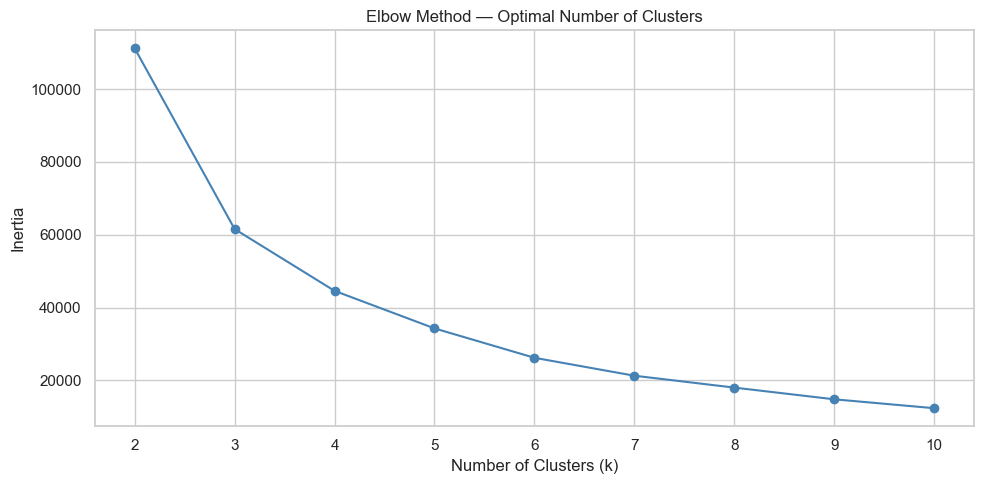

In [10]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.tight_layout()
plt.savefig('../outputs//elbow_chart.png', dpi=300)
plt.show()

## 6. Apply KMeans Clustering

In [11]:
# Apply KMeans with optimal k (adjust based on elbow chart)
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
customer_analysis['cluster'] = kmeans.fit_predict(df_scaled)

print('Cluster distribution:')
print(customer_analysis['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0    82569
1      751
2     9149
3      906
Name: count, dtype: int64


## 7. Analyse Clusters

In [12]:
# Cluster summary
cluster_summary = customer_analysis.groupby('cluster').agg(
    total_customers=('customer_unique_id', 'count'),
    avg_total_spent=('total_spent', 'mean'),
    avg_total_orders=('total_orders', 'mean'),
    avg_lifetime_days=('customer_lifetime_days', 'mean'),
    avg_order_value=('avg_order_value', 'mean')
).round(2)

print('Cluster Summary:')
print(cluster_summary)

Cluster Summary:
         total_customers  avg_total_spent  avg_total_orders  \
cluster                                                       
0                  82569           110.56              1.02   
1                    751           320.55              2.23   
2                   9149           490.80              1.08   
3                    906          1722.02              1.07   

         avg_lifetime_days  avg_order_value  
cluster                                      
0                     0.37           109.23  
1                   250.23           143.01  
2                     2.69           473.07  
3                     1.98          1669.36  


In [13]:
# Assign descriptive labels based on cluster characteristics
# Update these labels after reviewing the cluster summary above
cluster_labels = {
    0: 'Low Value / One-time',
    1: 'Mid Value / Occasional',
    2: 'High Value / Loyal',
    3: 'Premium / VIP'
}

customer_analysis['segment'] = customer_analysis['cluster'].map(cluster_labels)

print('Segment distribution:')
print(customer_analysis['segment'].value_counts())

Segment distribution:
segment
Low Value / One-time      82569
High Value / Loyal         9149
Premium / VIP               906
Mid Value / Occasional      751
Name: count, dtype: int64


## 8. Visualise Clusters

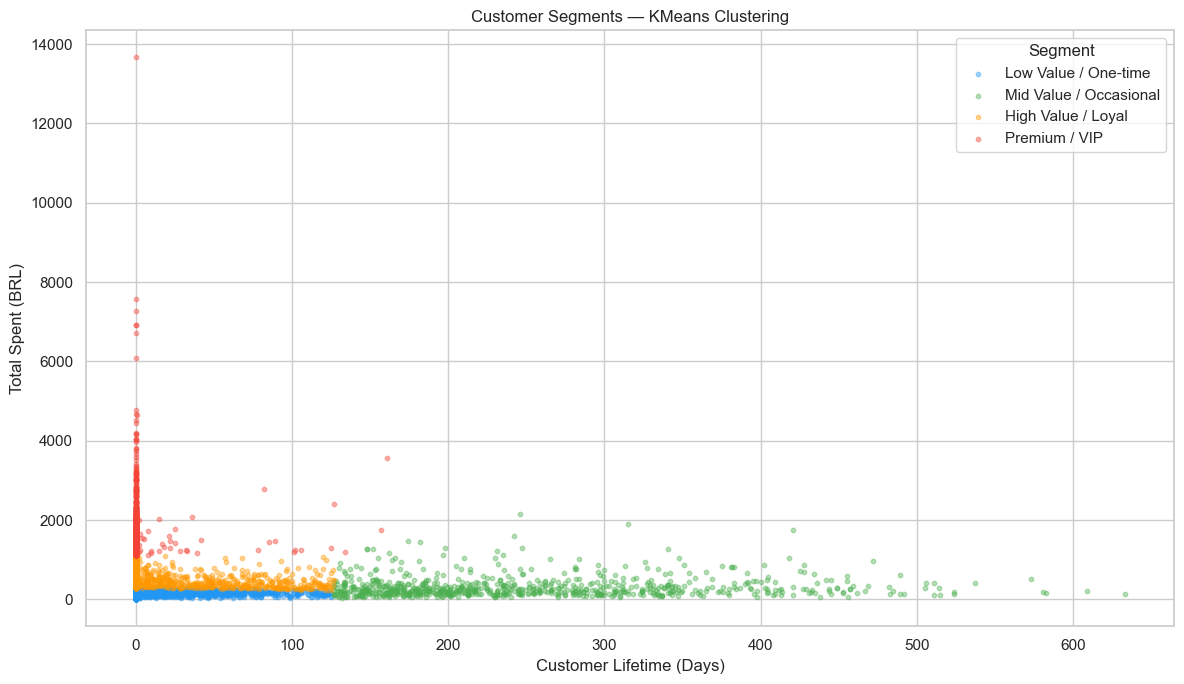

In [14]:
plt.figure(figsize=(12, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for cluster_id in range(OPTIMAL_K):
    cluster_data = customer_analysis[customer_analysis['cluster'] == cluster_id]
    plt.scatter(
        cluster_data['customer_lifetime_days'],
        cluster_data['total_spent'],
        alpha=0.4,
        s=10,
        color=colors[cluster_id],
        label=cluster_labels[cluster_id]
    )

plt.xlabel('Customer Lifetime (Days)')
plt.ylabel('Total Spent (BRL)')
plt.title('Customer Segments — KMeans Clustering')
plt.legend(title='Segment')
plt.tight_layout()
plt.savefig('../outputs///customer_segments.png', dpi=300)
plt.show()

## 9. Export for Power BI

In [15]:
customer_analysis.to_csv('../data///customer_segmentation.csv', index=False)
print('Customer segmentation exported successfully.')
print('Shape:', customer_analysis.shape)
print('Columns:', customer_analysis.columns.tolist())

Customer segmentation exported successfully.
Shape: (93375, 11)
Columns: ['customer_unique_id', 'market_region', 'total_orders', 'total_spent', 'avg_order_value', 'first_purchase', 'last_purchase', 'customer_type', 'customer_lifetime_days', 'cluster', 'segment']
